# Method 4 — Event Study: Dynamic Monthly Effects

**Logic:** Instead of collapsing to a single cumulative number, plot the month-by-month treatment effect. Pre-period bars should be near zero (no anticipation effect). Post-period bars show when, and by how much, the effect materialised.

In [1]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def fit_scm(Y_pre, X_pre):
    if X_pre.ndim == 1:
        X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(Y_pre - X_pre @ w)),
        [w >= 0, cp.sum(w) == 1]
    )
    prob.solve(solver=cp.SCS)
    return np.array(w.value).flatten()

def rmspe(a, b):
    return np.sqrt(np.mean((np.array(a) - np.array(b))**2))


## Data Preparation

In [2]:
df = pd.read_csv('./data/corridor.csv')
df['Date']        = df['Date'].astype(str).str.strip()
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

y_col       = 'Rail_Vol_mt'
treated     = 'NATCOR'
treat_start = pd.Period('2022-04', freq='M')
pre_end     = treat_start - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=y_col).sort_index()
donors   = [c for c in wide.columns if c != treated]
pre_idx  = wide.index[wide.index <= pre_end]
post_idx = wide.index[wide.index >= treat_start]
treat_t  = treat_start.to_timestamp()

# Base SCM gap
w_hat  = fit_scm(wide.loc[pre_idx, treated].values,
                 wide.loc[pre_idx, donors].values)
synth  = pd.Series(wide[donors].values @ w_hat, index=wide.index)
actual = wide[treated]
gap    = actual - synth

print(f'Pre periods : {len(pre_idx)} ({pre_idx[0]} – {pre_idx[-1]})')
print(f'Post periods: {len(post_idx)} ({post_idx[0]} – {post_idx[-1]})')


Pre periods : 87 (2015-01 – 2022-03)
Post periods: 33 (2022-04 – 2024-12)


## Event Study Calculation

In [3]:
# ── Method 4 : Event Study — Dynamic Monthly Effects ─────────────────────────
# Logic: Plot month-by-month treatment effect relative to treatment date.
# Pre-period bars ≈ 0 → no anticipation effect.
# Post-period bars show when and how much the effect materialised.

event_window_pre = 18   # months of pre-period to show in chart

show_idx    = wide.index[wide.index >= (treat_start - event_window_pre)]
rel_periods = np.array([(p - treat_start).n for p in show_idx])
gap_window  = gap.loc[show_idx].values
pre_window  = show_idx[show_idx < treat_start]
ci_band     = 1.96 * gap[pre_window].std()

print(f'Pre-period mean gap : {gap[pre_window].mean():.5f}  (should be ≈0 — no anticipation)')
print(f'Post-period mean gap: {gap[post_idx].mean():.5f}')
print(f'95% CI band width   : ±{ci_band:.4f}')

# Months where post effect is outside CI band
post_mask = rel_periods >= 0
significant = [(p, v) for p, v in zip(rel_periods[post_mask], gap_window[post_mask])
               if abs(v) > ci_band]
print(f'\nPost months outside ±1.96σ CI: {len(significant)} / {post_mask.sum()}')
for p, v in significant:
    print(f'  t+{p:2d}: {v:+.4f} MT')


Pre-period mean gap : -0.29211  (should be ≈0 — no anticipation)
Post-period mean gap: -0.33648
95% CI band width   : ±0.2648

Post months outside ±1.96σ CI: 22 / 33
  t+ 3: -0.2840 MT
  t+ 6: -0.3490 MT
  t+ 7: -0.4250 MT
  t+10: -0.3410 MT
  t+12: -0.3730 MT
  t+14: -0.2760 MT
  t+16: -0.3660 MT
  t+17: -0.4710 MT
  t+18: -0.4510 MT
  t+19: -0.4530 MT
  t+20: -0.4810 MT
  t+21: -0.3750 MT
  t+22: -0.5660 MT
  t+23: -0.3680 MT
  t+24: -0.3690 MT
  t+26: -0.3330 MT
  t+27: -0.3790 MT
  t+28: -0.3100 MT
  t+29: -0.4220 MT
  t+30: -0.6670 MT
  t+31: -0.6090 MT
  t+32: -0.4520 MT


## Figure 4 — Event Study Bar Chart

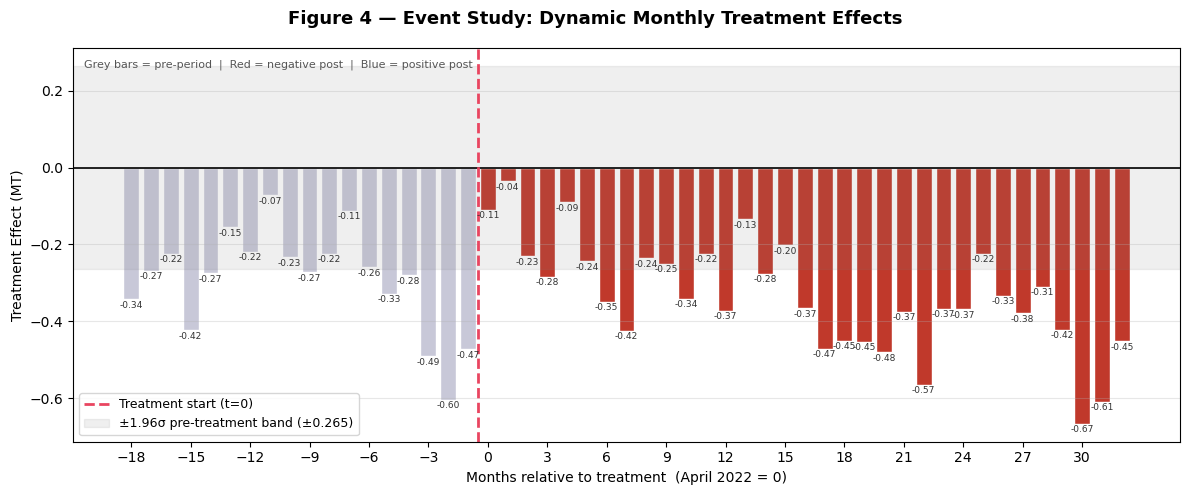

Figure saved → fig4_event_study.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Figure 4 — Event Study: Dynamic Monthly Treatment Effects',
             fontsize=13, fontweight='bold')

bar_colors = ['#c8c8d8' if p < 0 else ('#c0392b' if v < 0 else '#0f3460')
              for p, v in zip(rel_periods, gap_window)]
ax.bar(rel_periods, gap_window, color=bar_colors, edgecolor='white', width=0.8)

ax.axhline(0, color='black', lw=1.2)
ax.axvline(-0.5, color='#e94560', lw=2, ls='--', label='Treatment start (t=0)')
ax.axhspan(-ci_band, ci_band, alpha=0.12, color='grey',
           label=f'±1.96σ pre-treatment band (±{ci_band:.3f})')

for p, v in zip(rel_periods, gap_window):
    if abs(v) > 0.03:
        ax.text(p, v + (0.012 if v > 0 else -0.022),
                f'{v:.2f}', ha='center', fontsize=6.5, color='#333')

ax.set_xlabel('Months relative to treatment  (April 2022 = 0)')
ax.set_ylabel('Treatment Effect (MT)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(rel_periods[::3])

# Add colour legend annotation
ax.text(0.01, 0.97, 'Grey bars = pre-period  |  Red = negative post  |  Blue = positive post',
        transform=ax.transAxes, fontsize=8, va='top', color='#555')

plt.tight_layout()
plt.savefig('fig4_event_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → fig4_event_study.png')


## Monthly Effects Table (Post-Period)

In [5]:
# ── Monthly effects table (post-period) ───────────────────────────────────────
post_effects = pd.DataFrame({
    'Period': [str(p) for p in post_idx],
    'Relative month': range(len(post_idx)),
    'Gap (MT)': gap[post_idx].values.round(4),
    'Outside CI': [abs(v) > ci_band for v in gap[post_idx].values]
})
post_effects


,Period,Relative month,Gap (MT),Outside CI
0,2022-04,0,-0.110,False
1,2022-05,1,-0.036,False
2,2022-06,2,-0.231,False
3,2022-07,3,-0.284,True
4,2022-08,4,-0.090,False
5,2022-09,5,-0.244,False
6,2022-10,6,-0.349,True
7,2022-11,7,-0.425,True
8,2022-12,8,-0.236,False
9,2023-01,9,-0.251,False
